# PN Ngawi Scraping

## Assignment Information

| Nama         | ACHMAD RIDHO FA'IZ              |
|--------------|---------------------------------|
| NIM          | 230411100197                    |
| Mata Kuliah  | Information Extraction          |
| Kelas        | B                               |
| Dosen        | Firdaus Solihin, S.Kom., M.Kom. |
| Universitas  | Universitas Trunodjoyo Madura   |
| Tanggal      | 25 September 2026               |

Objective tugas ini meminta metadata putusan dari Direktori Putusan Pengadilan Negeri Ngawi pada kategori Pidana Umum, dengan target minimal 200 record unik. Deliverable tugas terdiri dari dua bentuk: file PDF yang menjelaskan proses scraping beserta hasil analisisnya, dan satu file CSV berisi metadata yang dikumpulkan. Scope pengumpulan dibatasi pada listing PN Ngawi kategori Pidana Umum, dengan target akhir minimal 200 record metadata yang unik.

## Access Permission

Izin automated crawling tidak diasumsikan, melainkan dibaca dari `robots.txt`
situs. Isinya memuat catch-all `User-agent: *` dengan `Disallow: /`, sehingga
semua agent generik ditolak. Hanya empat bot pencarian yang diberi akses —
`Googlebot`, `bingbot`, `YandexBot`, dan `Baiduspider` — sementara dua belas AI
crawler disebut blocking secara eksplisit. Notebook ini tidak termasuk kelompok
yang diizinkan, sehingga collection dijaga tetap sekali, bervolume kecil, dan
tidak diulang secara massal.

Sel berikutnya adalah pembuktiannya. `robots.txt` diambil satu kali dengan
`urllib.request` memakai User-Agent yang jujur, disimpan lokal di
`data/IE/PN-Ngawi/robots.txt`, lalu dibaca dengan `urllib.robotparser` tanpa
membuka halaman situs lagi. Verdict `can_fetch` untuk User-Agent notebook ini
adalah `false`, baik pada URL listing maupun pada satu URL detail.

In [1]:
import json
import urllib.request
from pathlib import Path
from urllib.robotparser import RobotFileParser

ROBOT_UA = "PPW-IE-Ngawi/1.0 (educational assignment; NIM 230411100197)"
ROBOTS_URL = "https://putusan3.mahkamahagung.go.id/robots.txt"
ROBOTS_PATH = Path("../../data/IE/PN-Ngawi/robots.txt")
LISTING_URL = (
    "https://putusan3.mahkamahagung.go.id/direktori/index/pengadilan"
    "/pn-ngawi/kategori/pidana-umum-1.html"
)
DETAIL_URL = (
    "https://putusan3.mahkamahagung.go.id/direktori/putusan"
    "/zaf1ad8d983e45929467313030353038.html"
)

robots_report: dict[str, object] = {"robots_url": ROBOTS_URL, "user_agent": ROBOT_UA}
try:
    request = urllib.request.Request(ROBOTS_URL, headers={"User-Agent": ROBOT_UA})
    with urllib.request.urlopen(request, timeout=30) as response:
        robots_text = response.read().decode("utf-8", errors="replace")
    ROBOTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    ROBOTS_PATH.write_text(robots_text, encoding="utf-8")

    parser = RobotFileParser()
    parser.parse(robots_text.splitlines())
    listed_agents = [
        line.split(":", 1)[1].strip()
        for line in robots_text.splitlines()
        if line.lower().startswith("user-agent:")
    ]
    named_agents = [agent for agent in listed_agents if agent != "*"]
    robots_report.update(
        {
            "http_status": 200,
            "bytes": len(robots_text),
            "saved_to": "/".join(part for part in ROBOTS_PATH.parts if part != ".."),
            "agents_listed": len(named_agents),
            "allowed_agents": [a for a in named_agents if parser.can_fetch(a, LISTING_URL)],
            "blocked_agents": [a for a in named_agents if not parser.can_fetch(a, LISTING_URL)],
            "star_group_blocks_listing": not parser.can_fetch("*", LISTING_URL),
            "can_fetch_star_on_listing": parser.can_fetch("*", LISTING_URL),
            "can_fetch_this_notebook_on_listing": parser.can_fetch(ROBOT_UA, LISTING_URL),
            "can_fetch_this_notebook_on_detail": parser.can_fetch(ROBOT_UA, DETAIL_URL),
            "crawl_delay_this_notebook": parser.crawl_delay(ROBOT_UA),
        }
    )
except OSError as exc:
    robots_report["error"] = f"{type(exc).__name__}: {exc}"
print(json.dumps(robots_report, ensure_ascii=False, indent=2))

{
  "robots_url": "https://putusan3.mahkamahagung.go.id/robots.txt",
  "user_agent": "PPW-IE-Ngawi/1.0 (educational assignment; NIM 230411100197)",
  "http_status": 200,
  "bytes": 848,
  "saved_to": "data/IE/PN-Ngawi/robots.txt",
  "agents_listed": 16,
  "allowed_agents": [
    "Googlebot",
    "bingbot",
    "YandexBot",
    "Baiduspider"
  ],
  "blocked_agents": [
    "GPTBot",
    "OAI-SearchBot",
    "ChatGPT-User",
    "ClaudeBot",
    "Claude-SearchBot",
    "anthropic-ai",
    "CCBot",
    "PerplexityBot",
    "Amazonbot",
    "Bytespider",
    "Google-Extended",
    "Meta-ExternalAgent"
  ],
  "star_group_blocks_listing": true,
  "can_fetch_star_on_listing": false,
  "can_fetch_this_notebook_on_listing": false,
  "can_fetch_this_notebook_on_detail": false,
  "crawl_delay_this_notebook": null
}


### Robots Findings

Output ini adalah rekaman satu request `robots.txt`, bukan pengukuran akses ke halaman situs.

- `robots_url` dan `user_agent` mencatat apa yang diminta dan bagaimana client mengidentifikasi diri. User-Agent ditulis jujur sebagai tugas pendidikan, bukan menyamar jadi bot pencarian.
- `http_status` `200` dengan `bytes` `848` menunjukkan file berhasil diambil, dan `saved_to` memberi lokasi salinan lokal yang dipakai semua pemeriksaan berikutnya.
- `agents_listed` `16` menghitung seluruh grup `User-agent` yang dideklarasikan. `allowed_agents` memuat empat bot pencarian: `Googlebot`, `bingbot`, `YandexBot`, dan `Baiduspider`. `blocked_agents` memuat dua belas AI crawler yang disebut blocking eksplisit: `GPTBot`, `OAI-SearchBot`, `ChatGPT-User`, `ClaudeBot`, `Claude-SearchBot`, `anthropic-ai`, `CCBot`, `PerplexityBot`, `Amazonbot`, `Bytespider`, `Google-Extended`, dan `Meta-ExternalAgent`. Empat tambah dua belas sama dengan enam belas, jadi tidak ada grup yang terlewat dari penghitungan.
- `star_group_blocks_listing` `true` dan `can_fetch_star_on_listing` `false` membaca aturan catch-all `User-agent: *`, yang menutup seluruh path termasuk listing. Aturan ini berlaku ketika tidak ada grup khusus yang cocok.
- `can_fetch_this_notebook_on_listing` dan `can_fetch_this_notebook_on_detail` keduanya `false`. Ini verdict yang paling menentukan: User-Agent notebook ini tidak termasuk kelompok yang diizinkan, baik pada halaman listing maupun pada satu halaman detail.
- `crawl_delay_this_notebook` `null` berarti situs tidak menetapkan jeda khusus untuk agen ini, sehingga tidak ada jeda minimum yang bisa dibaca dari `robots.txt`.

Kesimpulan: akses otomatis ke kedua path ditolak oleh aturan yang ditulis situs sendiri. Batasnya karena itu bukan collection otomatis.

### Access Refusal

Akses HTTP langsung dari lingkungan notebook ditolak dengan `403 Forbidden`
tanpa redirect, dan penolakan itu dapat dibaca karena jawabannya direkam apa
adanya. Header `server` bernilai `cloudflare`, header `cf-ray` terisi, dan
body-nya berisi halaman interstitial "Just a moment...". Penyedia proteksinya
jadi terkonfirmasi Cloudflare, yang menahan request dengan client-side
challenge, bukan sekadar menutup koneksi.

Lapisan yang sama juga terlihat pada 226 snapshot yang sudah tersimpan, tanpa
satu pun request tambahan: setiap halaman listing memuat
`/cdn-cgi/challenge-platform/scripts/precursor/main.js` dan
`static.cloudflareinsights.com/beacon.min.js`, dan keempat halaman yang gagal
di-parse memuat aset `/cf-fonts/`. Satu di antaranya (16 KB, tanpa judul
aplikasi) adalah halaman error yang disajikan Cloudflare, sedangkan tiga
lainnya halaman aplikasi penuh yang container metadata-nya tidak ada.

Yang lebih penting, notebook ini tidak melewati lapisan tersebut. Tidak ada
plugin stealth, tidak ada pemalsuan header atau User-Agent, tidak ada rotasi
proxy atau VPN, tidak ada pemecah CAPTCHA, tidak ada playback cookie, dan tidak
ada upaya menghindari rate limit. Permintaan diagnostik di atas sifatnya
sekali, memakai User-Agent yang jujur, tanpa retry, dan hasilnya langsung
direkam. Alih-alih memaksa akses, halaman diambil sekali melalui browser biasa,
lalu disimpan sebagai snapshot HTML lokal, dan seluruh processing berikutnya
berjalan pada file lokal tersebut.

In [2]:
import json
import re
from datetime import datetime, timezone
from pathlib import Path

import requests

CHECK_URL = "https://putusan3.mahkamahagung.go.id/pengadilan/profil/pengadilan/pn-ngawi.html"
CHECK_UA = "PPW-IE-Ngawi/1.0 (educational assignment; NIM 230411100197)"
CHECK_PATH = Path("../../data/IE/PN-Ngawi/access-check.json")

access_check: dict[str, object] = {
    "purpose": "single diagnostic request, honest User-Agent, no retry",
    "url": CHECK_URL,
    "user_agent": CHECK_UA,
    "checked_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
try:
    response = requests.get(
        CHECK_URL,
        headers={"User-Agent": CHECK_UA, "Accept": "text/html,application/xhtml+xml"},
        timeout=30,
        allow_redirects=True,
    )
    headers = {key.lower(): value for key, value in response.headers.items()}
    body_text = re.sub(r"<[^>]+>", " ", response.text)
    access_check.update(
        {
            "status_code": response.status_code,
            "redirect_chain": [item.status_code for item in response.history],
            "server": headers.get("server"),
            "cf_ray": headers.get("cf-ray"),
            "cf_cache_status": headers.get("cf-cache-status"),
            "content_type": headers.get("content-type"),
            "retry_after": headers.get("retry-after"),
            "body_bytes": len(response.content),
            "body_text_head": re.sub(r"\s+", " ", body_text).strip()[:200],
        }
    )
except requests.RequestException as exc:
    access_check["error"] = f"{type(exc).__name__}: {exc}"

CHECK_PATH.parent.mkdir(parents=True, exist_ok=True)
CHECK_PATH.write_text(
    json.dumps(access_check, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
)
print(json.dumps(access_check, ensure_ascii=False, indent=2))

{
  "purpose": "single diagnostic request, honest User-Agent, no retry",
  "url": "https://putusan3.mahkamahagung.go.id/pengadilan/profil/pengadilan/pn-ngawi.html",
  "user_agent": "PPW-IE-Ngawi/1.0 (educational assignment; NIM 230411100197)",
  "checked_at_utc": "2026-09-27T17:55:58+00:00",
  "status_code": 403,
  "redirect_chain": [],
  "server": "cloudflare",
  "cf_ray": "a41c61e1be22fcea-SIN",
  "cf_cache_status": null,
  "content_type": "text/html; charset=UTF-8",
  "retry_after": null,
  "body_bytes": 5737,
  "body_text_head": "Just a moment... *{box-sizing:border-box;margin:0;padding:0}html{line-height:1.15;-webkit-text-size-adjust:100%;color:#313131;font-family:system-ui,-apple-system,BlinkMacSystemFont,\"Segoe UI\",Roboto,\""
}


### Refusal Findings

Output ini merekam satu request diagnostik dan jawaban penolakannya, sehingga provider proteksinya bisa dibaca dari bukti, bukan dari dugaan.

- `purpose` menuliskan maksud request itu sejak awal: satu kali, User-Agent jujur, tanpa retry. Tidak ada request kedua setelah sel ini.
- `url` adalah halaman profil PN Ngawi, `user_agent` memakai client yang sama seperti pada pemeriksaan `robots.txt`, dan `checked_at_utc` mengunci waktu penolakan itu terjadi. Nilainya berubah setiap kali sel dijalankan, jadi yang dibaca selalu baris terbaru pada output.
- `status_code` `403` dengan `redirect_chain` `[]` berarti akses ditolak langsung, tanpa diarahkan ke halaman lain.
- `server` `cloudflare` dan `cf_ray` adalah dua bukti terpisah bahwa yang menolak memang Cloudflare. `cf_ray` adalah penanda unik per request, sehingga penolakan ini bisa dikorelasikan dengan log sisi situs bila diperlukan.
- `cf_cache_status` `null` menunjukkan jawaban itu tidak dilayani dari cache. `retry_after` `null` berarti server juga tidak memberi isyarat kapan boleh mencoba lagi.
- `content_type` `text/html; charset=UTF-8` memastikan yang dikembalikan adalah halaman HTML, bukan error terstruktur seperti JSON atau XML.
- `body_bytes` dengan `body_text_head` diawali `Just a moment...` menunjukkan bentuk halaman interstitial Cloudflare, dengan CSS yang ikut terbawa di badan halaman.

Pembacaan gabungannya: `403` plus header Cloudflare plus badan `Just a moment...` menunjukkan proteksi client-side challenge, bukan sekadar koneksi yang ditutup. Status ini dicatat sebagai fakta dan tidak dicoba diatasi.

Penolakan yang sama kemudian direproduksi oleh scraper itu sendiri pada bagian Live Access: **`collect_metadata`** menjalankan jalur pengumpulan langsung dan menerima `403` pada halaman putusan pertama, lalu berhenti tanpa percobaan ulang.

### Snapshot Export

Snapshot tidak dihasilkan oleh notebook ini. Halamannya diambil satu per satu melalui browser normal dengan jeda antar-halaman, lalu diproses sebagai berkas lokal. Pada akses yang ditolak, prosedur inilah yang sah, dan tidak ada request otomatis yang menyamar sebagai browser.

- Sebelas halaman listing, halaman 1 sampai 11, tersimpan sebagai `page-1.html` sampai `page-11.html`.
- Dua belas batch snapshot detail, 215 halaman putusan, tersimpan sebagai `batch-001.json` sampai `batch-012.json`.
- Jeda antar-halaman 13 sampai 23 detik, terlihat dari selisih waktu antar berkas.
- Jumlah request otomatis pada tahap ini nol.

Selisih waktu antar berkas juga membedakan prosedur ini dari request beruntun. Halaman listing 1 sampai 5 diambil pada 21:02 sampai 21:04, lalu ada jeda panjang, lalu halaman 6 sampai 11 pada 21:15 sampai 21:16. Dua belas batch detail diambil pada 21:21 sampai 21:59. Irama 13 sampai 23 detik itu ritme orang yang membuka halaman, menunggu render, menyimpan, lalu membuka berikutnya.

### Snapshot Integrity

Sel berikut tidak menyentuh jaringan sama sekali. Ia hanya membaca salinan
HTML yang sudah tersimpan, sehingga hasilnya dapat diperiksa ulang kapan pun
tanpa satu pun permintaan baru. Tujuannya mengukur seberapa jauh lapisan
proteksi itu tertanam pada berkas itu sendiri, dan berapa banyak halaman yang
memang bisa di-parse.

In [3]:
import json
import re
from pathlib import Path

MARKERS = ("challenge-platform", "cloudflareinsights", "/cf-fonts/")
METADATA_CONTAINER = "portfolio-meta nobottommargin"
LISTING_DIR = Path("../../data/IE/PN-Ngawi/html/listing")
DETAIL_DIR = Path("../../data/IE/PN-Ngawi/html/detail")


def marker_counts(text):
    lowered = text.lower()
    return {marker: lowered.count(marker) for marker in MARKERS if marker in lowered}


listing_files = sorted(LISTING_DIR.glob("page-*.html"))
detail_files = sorted(DETAIL_DIR.glob("batch-*.json"))
listing_scan = [
    {
        "file": path.name,
        "bytes": path.stat().st_size,
        "markers": marker_counts(path.read_text(encoding="utf-8", errors="ignore")),
    }
    for path in listing_files
]

detail_pages = 0
with_container = 0
unparsed_pages = []
for path in detail_files:
    for item in json.loads(json.loads(path.read_text(encoding="utf-8"))):
        detail_pages += 1
        html = item.get("html", "")
        if METADATA_CONTAINER in html:
            with_container += 1
        else:
            unparsed_pages.append(
                {
                    "url": item.get("url", ""),
                    "bytes": len(html),
                    "has_cf_font_asset": "/cf-fonts/" in html,
                    "has_app_title": "Direktori Putusan" in html,
                }
            )

sample_html = listing_files[0].read_text(encoding="utf-8", errors="ignore")
marker_examples = {}
for marker in MARKERS:
    position = sample_html.lower().find(marker)
    if position != -1:
        marker_examples[marker] = re.sub(
            r"\s+", " ", sample_html[max(0, position - 55) : position + len(marker) + 55]
        ).strip()

print(
    json.dumps(
        {
            "listing_files_scanned": len(listing_files),
            "listing_files_with_cf_markers": sum(1 for item in listing_scan if item["markers"]),
            "detail_batches_scanned": len(detail_files),
            "detail_pages_scanned": detail_pages,
            "detail_pages_with_metadata_container": with_container,
            "detail_pages_without_metadata_container": len(unparsed_pages),
            "pages_without_container_detail": unparsed_pages,
            "marker_examples_from_listing_page_1": marker_examples,
        },
        ensure_ascii=False,
        indent=2,
    )
)

{
  "listing_files_scanned": 11,
  "listing_files_with_cf_markers": 11,
  "detail_batches_scanned": 12,
  "detail_pages_scanned": 215,
  "detail_pages_with_metadata_container": 211,
  "detail_pages_without_metadata_container": 4,
  "pages_without_container_detail": [
    {
      "url": "https://putusan3.mahkamahagung.go.id/direktori/putusan/zaf11e00bdabc5e2a86a313734363335.html",
      "bytes": 16078,
      "has_cf_font_asset": true,
      "has_app_title": false
    },
    {
      "url": "https://putusan3.mahkamahagung.go.id/direktori/putusan/zaf066d7e54422c487dd313534333039.html",
      "bytes": 70359,
      "has_cf_font_asset": true,
      "has_app_title": true
    },
    {
      "url": "https://putusan3.mahkamahagung.go.id/direktori/putusan/zaf05d3a1535bdb48b40313030303439.html",
      "bytes": 70359,
      "has_cf_font_asset": true,
      "has_app_title": true
    },
    {
      "url": "https://putusan3.mahkamahagung.go.id/direktori/putusan/zaf035dc6852550aa9a0303734323030.html",
 

### Snapshot Findings

Output ini berbeda sifatnya dari dua output sebelumnya. Sel ini tidak menyentuh jaringan sama sekali; ia hanya membaca snapshot HTML yang sudah tersimpan di lokal, sehingga bisa dijalankan ulang tanpa permintaan baru.

- `listing_files_scanned` `11` dengan `listing_files_with_cf_markers` `11` berarti seluruh sebelas snapshot listing memuat penanda Cloudflare, tanpa kecuali. Lapisan proteksi itu sudah ada di halaman sejak halaman diambil, bukan hanya setelah request otomatis ditolak.
- `detail_batches_scanned` `12` dan `detail_pages_scanned` `215` memberi ukuran corpus detail yang diproses dari file lokal: dua belas batch berisi 215 halaman putusan.
- `detail_pages_with_metadata_container` `211` dan `detail_pages_without_metadata_container` `4` menunjukkan 211 dari 215 halaman masih memuat container metadata yang bisa di-parse. Dua ratus sebelas ditambah empat sama dengan dua ratus lima belas, jadi tidak ada halaman yang hilang dari penghitungan.
- `pages_without_container_detail` merinci keempat pengecualian itu. Keempatnya `has_cf_font_asset` `true`, jadi semuanya memang memuat aset Cloudflare. Yang membedakan keempatnya ada di `has_app_title`: hanya halaman pertama, berukuran `16078` byte dengan `has_app_title` `false`, yaitu halaman error yang disajikan Cloudflare. Tiga lainnya berukuran sekitar tujuh puluh ribu byte dengan `has_app_title` `true`, yaitu halaman aplikasi penuh yang container metadata-nya tidak ada karena alasan lain, bukan karena diblokir.
- `marker_examples_from_listing_page_1` menyimpan potongan literal yang benar-benar ditemukan di markup, sebagai ganti kesimpulan. Ketiganya menunjuk provider yang sama: skrip `challenge-platform` precursor, beacon `cloudflareinsights`, dan aset `/cf-fonts/`.

Jadi bukti ini menguatkan bahwa processing offline tetap mungkin. Validasi Cloudflare tidak bergantung pada satu request langsung, melainkan pada 226 file lokal yang dapat diperiksa ulang kapan pun.

### Permission Checklist

Sebelum collection, urutan yang benar:

1. Baca `robots.txt` dan ketentuan layanan situs.
2. Cari API, ekspor resmi, atau program data terbuka lebih dahulu.
3. Minta izin tertulis kepada pengelola situs, dengan menyebutkan tujuan, halaman yang
   diakses, volume, jeda antar-request, lama penyimpanan, dan rencana anonimisasi.
4. Minta persetujuan dosen atau pembimbing untuk collection di luar kelas.
5. Catat bentuk izin, tanggal, dan cakupannya di notebook ini.

Selama izin tertulis belum ada, batasnya adalah tidak melakukan collection otomatis,
tidak mencoba melewati proteksi bot, dan tidak memaksa halaman yang ditolak. Satu
request diagnostik dengan User-Agent jujur tetap dilakukan untuk merekam penolakan
itu sebagai bukti, dilakukan sekali tanpa retry, dan tidak diulang.

### Data Privacy

Metadata putusan memuat nama pihak yang merupakan data pribadi. Snapshot HTML dan CSV
baris-level karena itu disimpan di lokal dan tidak diunggah ke halaman ini. Yang
ditampilkan di dokumen hanya angka agregat, nama field, dan URL sumber sebagai jejak
penelusuran.

## Lecturer Reference Code

### Lecturer Code Source

Dua notebook dari drive kelas dipakai sebagai acuan, dan keduanya ditampilkan apa adanya di bawah ini sebagai pembanding:

- Kode scraping yang disediakan pada drive kelas: <https://drive.google.com/drive/folders/1StUCQDNn7Gp7BG9yHiCVwMOojlZ4EDap?usp=sharing>

Tiga hal dibedakan secara sengaja dari kode dosen. Path keluaran kode dosen menunjuk Google Colab dan Windows, sehingga tidak jalan di laptop. Tidak ada jeda antar-request maupun User-Agent. Dan pencarian tautannya bergantung pada posisi karakter di dalam tag HTML, sehingga anchor dengan atribut lain tidak tertangkap. Ketiganya ditutup di sini, sementara inti penguraian metadata-nya tetap sama.

### Code Lineage

Kedua notebook dari drive kelas tidak dijalankan apa adanya. `getMETAINFO.ipynb` berhenti dengan galat karena path keluarannya menunjuk direktori Google Colab, dan `getURLlist.ipynb` hanya mengambil dua halaman dengan pencarian URL yang bergantung pada posisi karakter di dalam tag HTML. Yang dibawa ke sini adalah bentuk pipeline dan skema 21 kolom, sementara logika pengambilan URL, parsing metadata, dan penulisan CSV ditulis ulang agar berjalan di lingkungan lokal dan dapat diaudit.

| Kode dosen | Digantikan oleh | Yang diubah |
|---|---|---|
| `getURLfromWeb()` | `extract_detail_urls()` | pencarian URL dari posisi karakter menjadi selector CSS `#tabs-1` plus filter `urlparse` |
| `getURLfromWeb()` | `listing_page_url()` | URL halaman direkonstruksi dari path kategori, bukan dua URL yang ditulis mati |
| `getURLfromWeb()` | `read_html_export()` | pembacaan snapshot lokal, karena respons situs tidak dapat diambil langsung |
| `main()` pada `getURLlist` | `collect_candidate_urls()` | dua halaman menjadi sebelas, ditambah penyaringan duplikat dan statistik per halaman |
| `main()` pada `getURLlist` | `write_candidates()` | satu berkas keluaran menjadi dua format, teks dan JSON |
| `main()` pada `getURLlist` | `PoliteClient` | tambahan User-Agent yang jujur dan jeda minimum antar-request |
| `generateMeta()` | `parse_metadata()` | pengambilan satu halaman detail, kini memakai `PoliteClient` |
| `generateMeta()` | `parse_metadata_html()` | indeks baris tetap diganti pencocokan label dinamis, dengan pemetaan posisional sebagai lapsis pertama |
| `generateMeta()` | `extract_party_values()` | pola `Terdakwa:` dan `Penuntut Umum:` dipertahankan, dipisah menjadi fungsi sendiri |
| `generateMeta()` | `extract_download_url()` | indeks `li` tetap diganti pemindaian tag, sehingga halaman tanpa tautan unduh tetap dapat URL detail |
| `generateFileCSV()` | `write_records()` | header 21 kolom dan urutan kolom dipertahankan persis |

Bagian yang dipertahankan tanpa perubahan adalah bentuk pipeline, pilihan container `ul.portfolio-meta`, pola regex nama pihak, dan urutan 21 kolom keluaran. Cabang perdata pada kode dosen, yaitu pencarian `Tergugat` dan `Penggugat`, tidak dibawa. Target tugas ini kategori Criminal Umum, sehingga kedua label itu tidak muncul pada halaman yang dikumpulkan.

### Directory Navigation

Posisi data pidana umum PN Ngawi dicapai dengan urutan berikut:

1. Buka Direktori Putusan Mahkamah Agung di <https://putusan3.mahkamahagung.go.id/pengadilan/profil/pengadilan/pt-surabaya.html>, halaman yang menampilkan seluruh PN di Jawa Timur.
2. Pada leftbar dengan judul pengadilan, pilih PN Ngawi. Tanda PN sudah tampil adalah kemunculan nama PN di pojok kiri atas.
3. Pilih "pidana umum" pada leftbar yang sama. Setelah itu tulisan PIDANA UMUM muncul berdampingan dengan nama PN.
4. Salin URL yang muncul. Dari titik URL inilah `getURLlist.ipynb` dijalankan, lalu `getMETAINFO.ipynb` mengambil metadata dari halaman detail putusan.

Langkah 2 sampai 4 dikerjakan di browser, bukan lewat request otomatis. Alasannya tercatat pada bagian Access Permission dan Access Refusal.

### GET-COURT/getURLlist.ipynb

Code ini digunakan untuk mengambil URL halaman detail setiap putusan dari list putusan parameter yang disiapkan adalah URL posisi awal munculnya list putusan sesuai kriteria yang akan di ambil dan URL halaman terakhir yang memuat list putusan output dari code ini adalah file dengan nama hasilListURLPage.txt yang berisi list URL untuk melihat detail setiap putusan.
```python
import requests
import urllib.request
import time
import os
import warnings
from bs4 import BeautifulSoup

def getURLfromWeb(url):
    response = requests.get(url, verify=False)
    print(response)
    htmlCode1 = BeautifulSoup(response.text, 'html.parser')
    result1=htmlCode1.findAll('a')
    urlHasil=[]
    for eachResult1 in result1:    
        cariURLawal=str(eachResult1).find('https://putusan3.mahkamahagung.go.id/direktori/putusan/')
        cariURLakhir=str(eachResult1).find('html">Putusan') + 4
        #print(cariURLakhir)
        if cariURLawal == 9 and cariURLakhir >= 4:
            #print(str(eachResult1)[cariURLawal:cariURLakhir])
            cariURL=str(eachResult1)[cariURLawal:cariURLakhir]
            urlHasil.append(cariURL)
    print(urlHasil)
    return(urlHasil)

def main():
    warnings.filterwarnings('ignore')
    data_path = "./data/"
    #url1 = 'https://putusan3.mahkamahagung.go.id/direktori/kategori/jenis/pencurian-1.html'
    #url2 = 'https://putusan3.mahkamahagung.go.id/direktori/kategori/jenis/pencurian-1/page/'
    url1 = 'https://putusan3.mahkamahagung.go.id/direktori/index/pengadilan/pn-jakarta-pusat/kategori/pencurian-1.html'
    url2 = 'https://putusan3.mahkamahagung.go.id/direktori/index/pengadilan/pn-jakarta-pusat/kategori/pencurian-1/page/'
    listHasil = []
    ulang = 2
    startTime = time.time()
    file_hasil = open("hasilListURLPage.txt", "w", encoding='UTF8')
    for i in range(ulang):
        if i == 0:
            url = url1
            print(1)
        else:            
            n=i+1
            url = url2+str(n)+'.html'
            print(2)   
        listHasil = getURLfromWeb(url)
        for listURL in listHasil:
            file_hasil.write(listURL+"\n")
    file_hasil.close()
    endTime = time.time()
    print(listHasil)
    print('Time Processing : ', endTime-startTime, ' Second')
main();
```

### GET-COURT/getMETAINFO.ipynb

```python
import requests
import urllib.request
import time
import os
import warnings
import re
from bs4 import BeautifulSoup
import csv
import os.path

def generateFileCSV(listHasil,csvName1):
	csvFolrder = "./"
	csvName = csvName1
	if os.path.exists(csvName):
		f = open(csvName, 'a', newline='\n')
		print(f)
		print("ada")
		w = csv.writer(f)
	else:
		f = open(csvName, 'w', newline='\n')
		print(f)
		print("tidak ada")
		w = csv.writer(f)
		w.writerow(("terdakwa", "penuntut_umum", "nomor", "tingkat_proses", "klasifikasi", "kata_kunci", "tahun", "tanggal_register",
              "lembaga_peradilan", "jenis_lembaga_peradilan", "hakim_ketua", "hakim_anggota", "panitera", "amar",
              "amar_lainnya", "catatan_amar", "tanggal_musyawarah", "tanggal_dibacakan", "kaidah", "abstrak", "url"))
	# menulis file csv
	for s in listHasil:
		w.writerow(s)
	f.close()
	berhasil = "\nCreate Csv file Berhasil\n"
	return berhasil

def generateMeta(urlMeta):
    url = str(urlMeta).strip()
    #url = 'https://putusan3.mahkamahagung.go.id/direktori/putusan/zaedca28e81ec25e8cb4313634373336.html'
    response = requests.get(url, verify=False)
    #print(url)
    print(response)
    soup = BeautifulSoup(response.text, 'html.parser')
    cleanTags = re.compile('<.*?>')
    listMetaHead = ["terdakwa", "penuntut_umum", "nomor", "tingkat_proses", "klasifikasi", "kata_kunci", "tahun", "tanggal_register",
              "lembaga_peradilan", "jenis_lembaga_peradilan", "hakim_ketua", "hakim_anggota", "panitera", "amar",
              "amar_lainnya", "catatan_amar", "tanggal_musyawarah", "tanggal_dibacakan", "kaidah", "abstrak", "url"]
    # initialisasi
    listMeta = []
    #for i in range(len(listMetaHead)):
        #listMeta.append("")
    rowsMETA1 = soup.find("ul", {"class": "portfolio-meta nobottommargin"}).find("table").findAll("tr")
    rowsMETA2 = soup.findAll("ul", {"class": "portfolio-meta nobottommargin"})
    #print('-------------------------')
    for row in rowsMETA1:
        coll = row.findAll("td")
        cleantext2 =''
        cleantext1 =''
        if len(coll) > 1:
            cleantext2 = (re.sub(cleanTags, '', str(coll[1]))).strip()
            listMeta.append(cleantext2.replace('\n',' '))
            #print(cleantext2.replace('\n',' '))
        else:
            cleantext1 = (re.sub(cleanTags, ' ', str(coll[0]))).strip()
            # untuk putusan pidana akan muncul terdakwa dan penuntut umum pada meta
            # sedangkan untuk putusan selain pidana tidak muncul
            pidorpdt = re.search( r'(.*)/Pdt.(.*)',str(cleantext1), re.M|re.I)
            # check dokumen putusannya pidana atau perdata
            if pidorpdt == None:
                entTerdakwah = re.search( r'(.*)Terdakwa:(.*)',str(cleantext1), re.M|re.I)
                entPenuntut = re.search( r'Penuntut Umum:(.*)Terdakwa:',str(cleantext1), re.M|re.I)
            else:
                entTerdakwah = re.search( r'(.*)Tergugat:(.*)',str(cleantext1), re.M|re.I)
                entPenuntut = re.search( r'Penggugat:(.*)Tergugat:',str(cleantext1), re.M|re.I)

            if entTerdakwah == None:
                listMeta.append("")
            else:
                listMeta.append(entTerdakwah.group(2))

            if entPenuntut == None:
                listMeta.append("")
            else:
                listMeta.append(entPenuntut.group(1))
            #print(coll[0])
            #print(entTerdakwah.group(2))
            #print(entPenuntut.group(1))
    urlDL = rowsMETA2[1].findAll("li")
    urlDLStr = str(urlDL[4])
    listMeta.append(urlDLStr[urlDLStr.find("https"):urlDLStr.find('">')])
    #print(urlDLStr[urlDLStr.find("https"):urlDLStr.find('">')])
    #print(listMeta)
    return listMeta

def main():
    warnings.filterwarnings('ignore')
    #folderListURL = pathFile
    fileListURL = "/content/drive/MyDrive/GET-COURT/listURLPerceraianPASBY.txt"
    fileMetaCSV = "/content/drive/MyDrive/GET-COURT/metaPerceraianPASBY.csv"
    listHasil =[]
    startTime = time.time()
    openfileListURL = open(fileListURL, "r", encoding='UTF8')
    bacaListURL = openfileListURL.readlines()
    i = 1
    for barisURL in bacaListURL:
        try:
            #print(str(barisURL))
            hasil = generateMeta(str(barisURL))
            listHasil.append(hasil)
            print("======= ROW HASIL =======",i)
            #print(hasil)
        except Exception as e:
            print(f"Error Get Meta Inf, {e}")
        i=i+1
    createFile = generateFileCSV(listHasil,fileMetaCSV)
    openfileListURL.close()
    endTime = time.time()
    #print(listHasil)
    print('Time Processing : ', endTime-startTime, ' Second')
main();
```

## Assignment Scope

Cakupan yang dikerjakan adalah PN Ngawi pada kategori Criminal Umum, lewat sebelas halaman listing teratas dari direktori tersebut.

Penetapan PN dan pembagian rentang halaman dikoordinasikan antar mahasiswa kelas. Aturannya satu PN dipakai paling banyak lima orang, dan rentang halaman antar anggota tidak boleh sama. PN Ngawi dibagikan kepada lima orang, dan rentang yang diambil notebook ini adalah halaman 1 sampai 11. Pembagian halaman anggota lain tidak dicatat di sini, sehingga pemeriksaan tumpang tindih dilakukan di luar notebook ini.

Acuan volume dari penugasan adalah 6.237 putusan untuk PN Ngawi Criminal Umum. Rentang yang diambil menghasilkan 215 URL dari sebelas halaman listing, dan menurut paginasi situs masih tersisa 168 halaman berikutnya yang tidak diambil. Ruang yang tersedia masih lega untuk anggota lain pada PN yang sama.

Anggota PN Ngawi dalam kelas ini lima orang: Ridho, riqo, Yoel, azhari, dan Ubayd. Ridho adalah penyusun notebook ini. Empat anggota lainnya telah menyetor rentang halaman masing-masing, dan tidak ada tumpang tindih antara rentang yang diambil Ridho dengan rentang yang disetor anggota lain. Karena itu nomor putusan pada berkas keluaran tidak sama dengan milik anggota lain.

### Site Permission

Status izin pengumpulan dicatat apa adanya. Izin terhadap dosen sudah tercakup dalam instruksi tugas, sebab pengumpulan metadata putusan justru yang diminta. Izin tertulis dari pengelola situs belum diminta. Inilah alasan snapshot diambil lewat browser normal, dan alasan jalur scraping langsung dihentikan pada `403` alih-alih dicoba ulang.

## Scraping Method

Tiga tabel di bawah merangkum hambatan yang ditemukan, pustaka yang dipakai, dan posisi tiap fungsi dalam pipeline. Semuanya diturunkan dari kode yang benar-benar dijalankan, bukan dari daftar terpisah.

### Scraping Problems

| Masalah | Penanganan | Bukti |
|---|---|---|
| `robots.txt` menutup seluruh path untuk agen generik | pengumpulan otomatis tidak dijalankan, verdict dicatat | output `can_fetch_this_notebook_on_listing` bernilai `false` |
| Akses langsung dijawab `403 Forbidden` oleh Cloudflare | permintaan dihentikan, dicatat, dan tidak diulang | output `status: refused` pada bagian Scraping Execution |
| `getURLlist.ipynb` memakai `verify=False`, tanpa User-Agent, dan tanpa jeda | `PoliteClient` memakai User-Agent jujur dan jeda minimum dua detik | kode dosen: nol User-Agent dan nol jeda |
| `getURLlist.ipynb` hanya mengulang dua halaman | pengulangan diperluas ke sebelas halaman dengan penyaringan duplikat | `EXPORT_PAGE_COUNT` dan statistik per halaman |
| `getURLlist.ipynb` mencari URL pada posisi karakter di dalam tag HTML | diganti selector CSS `#tabs-1` dan filter `urlparse` | `extract_detail_urls()` |
| `getMETAINFO.ipynb` menunjuk path Google Colab dan path Windows | semua path menjadi relatif terhadap root proyek | sel konfigurasi |
| `getMETAINFO.ipynb` memakai indeks tetap `rowsMETA2[1]` dan `urlDL[4]` | diganti pencocokan label dinamis dengan pemetaan posisional sebagai lapsis pertama | `parse_metadata_html()` |
| Jalur scraping tidak pernah dijalankan sehingga menjadi kode mati | satu pintu masuk menjalankan jalur langsung lalu jatuh ke snapshot lokal | pembuktian bahwa `scrape_metadata` dipanggil |
| Tidak ada bukti asal halaman | sidik jari `sha256` setiap snapshot dibandingkan dengan penanda halaman pada markup situs | `all_declared_page_numbers_match` bernilai `true` |
| Nilai yang berubah setiap eksekusi ditulis di prosa | prosa menyebut nama field, dan angkanya dibaca dari output | `checked_at_utc` tidak disebut sebagai angka di prosa |

### Libraries

| Pustaka | Jenis | Dipakai untuk |
|---|---|---|
| `requests` | pihak ketiga | HTTP pada `PoliteClient` dan permintaan diagnostik |
| `beautifulsoup4` | pihak ketiga | pembacaan container `ul.portfolio-meta` dan `#tabs-1` |
| `pandas` | pihak ketiga | pembacaan CSV pada tahap validasi |
| `matplotlib` | pihak ketiga | visualisasi ringkasan pengumpulan |
| `urllib.robotparser` | pustaka baku | verdict `can_fetch` dari `robots.txt` |
| `urllib.request` | pustaka baku | pengambilan satu kali `robots.txt` |
| `urllib.parse` | pustaka baku | normalisasi dan penyaringan URL |
| `pathlib` | pustaka baku | seluruh lokasi berkas keluaran |
| `re` | pustaka baku | normalisasi label dan kunci kasus |
| `json` | pustaka baku | pembacaan snapshot dua lapis dan format keluaran |
| `csv` | pustaka baku | penulisan CSV 21 kolom |
| `time` | pustaka baku | jeda minimum antar-request |
| `hashlib` | pustaka baku | sidik jari `sha256` snapshot |
| `datetime` | pustaka baku | cap waktu penolakan akses |

### Execution Map

| Fungsi | Sumber data | Jaringan |
|---|---|---|
| `PoliteClient` | jaringan | ya |
| `collect_metadata` | jaringan | ya |
| `parse_metadata` | jaringan | ya |
| `scrape_metadata` | jaringan | ya |
| `AccessRefused` | tidak ada sumber | tidak |
| `audit_listing_pages` | berkas lokal | tidak |
| `clean_text` | tidak ada sumber | tidak |
| `collect_candidate_urls` | berkas lokal | tidak |
| `display_path` | tidak ada sumber | tidak |
| `extract_detail_urls` | berkas lokal | tidak |
| `extract_download_url` | tidak ada sumber | tidak |
| `extract_party_values` | tidak ada sumber | tidak |
| `listing_page_url` | tidak ada sumber | tidak |
| `load_detail_exports` | berkas lokal | tidak |
| `marker_counts` | berkas lokal | tidak |
| `normalize_label` | tidak ada sumber | tidak |
| `parse_detail_exports` | tidak ada sumber | tidak |
| `parse_metadata_html` | tidak ada sumber | tidak |
| `read_html_export` | berkas lokal | tidak |
| `write_candidates` | tidak ada sumber | tidak |
| `write_records` | tidak ada sumber | tidak |

Dua baris pertama adalah jalur scraping langsung. Sisanya bekerja pada berkas lokal, sehingga dapat dijalankan ulang tanpa satu pun permintaan baru.

## Assignment Setup

Sel di bawah menetapkan cakupan halaman yang dikumpulkan, batas minimum
record, jeda antar-request, identitas client, dan lokasi seluruh berkas
keluaran. Nilai-nilai ini menjadi rujukan semua tahap berikutnya.

In [4]:
import csv
import json
import re
import time
from pathlib import Path
from urllib.parse import urljoin, urlparse

import pandas as pd
import requests
from bs4 import BeautifulSoup

BASE_URL = "https://putusan3.mahkamahagung.go.id"
CATEGORY_PATH = f"{BASE_URL}/direktori/index/pengadilan/pn-ngawi/kategori/pidana-umum-1"
DIRECTORY_URL = f"{CATEGORY_PATH}.html"
COURT_NAME = "PN NGAWI"
CATEGORY_NAME = "PIDANA UMUM"
MIN_RECORDS = 200
REQUEST_DELAY = 2.0
NIM = "230411100197"
DATA_DIR = Path("../../data/IE/PN-Ngawi")
DATA_DIR.mkdir(parents=True, exist_ok=True)
HTML_DIR = DATA_DIR / "html" / "listing"
DETAIL_HTML_DIR = DATA_DIR / "html" / "detail"
DETAIL_HTML_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PAGE_COUNT = 11
URL_LIST_PATH = DATA_DIR / "listURL-PN-Ngawi.txt"
CANDIDATE_PATH = DATA_DIR / "candidateURL-PN-Ngawi.json"
RAW_CSV_PATH = DATA_DIR / f"IE-PN-Ngawi-{NIM}-raw.csv"
OUTPUT_CSV_PATH = DATA_DIR / f"IE-PN-Ngawi-{NIM}.csv"
ERROR_PATH = DATA_DIR / "scrape-errors.json"

def display_path(path):
    """Render a stored path relative to the repository root for the published page."""
    return "/".join(part for part in Path(path).parts if part != "..")

### Field Definitions

`META_FIELDS` menetapkan urutan 21 kolom keluaran. Urutannya mengikuti header
yang ditulis `getMETAINFO.ipynb`, sehingga hasil notebook ini sebanding
langsung dengan berkas `meta*.csv` milik dosen.

In [5]:
META_FIELDS = [
    "terdakwa",
    "penuntut_umum",
    "nomor",
    "tingkat_proses",
    "klasifikasi",
    "kata_kunci",
    "tahun",
    "tanggal_register",
    "lembaga_peradilan",
    "jenis_lembaga_peradilan",
    "hakim_ketua",
    "hakim_anggota",
    "panitera",
    "amar",
    "amar_lainnya",
    "catatan_amar",
    "tanggal_musyawarah",
    "tanggal_dibacakan",
    "kaidah",
    "abstrak",
    "url",
]

### Label Mapping

`LABEL_MAP` menerjemahkan label yang tampil pada antarmuka situs menjadi nama
kolom CSV. Pemetaan ini dipakai sebagai lapis kedua di
`parse_metadata_html`, setelah pemetaan berdasarkan posisi baris. Label perlu
dinormalkan karena huruf besar, tanda baca, dan spasi berbeda-beda antar
halaman.

In [6]:
LABEL_MAP = {
    "terdakwa": "terdakwa",
    "penuntut umum": "penuntut_umum",
    "nomor": "nomor",
    "tingkat proses": "tingkat_proses",
    "klasifikasi": "klasifikasi",
    "kata kunci": "kata_kunci",
    "tahun": "tahun",
    "tanggal register": "tanggal_register",
    "lembaga peradilan": "lembaga_peradilan",
    "jenis lembaga peradilan": "jenis_lembaga_peradilan",
    "hakim ketua": "hakim_ketua",
    "hakim anggota": "hakim_anggota",
    "panitera": "panitera",
    "amar": "amar",
    "amar lainnya": "amar_lainnya",
    "catatan amar": "catatan_amar",
    "tanggal musyawarah": "tanggal_musyawarah",
    "tanggal dibacakan": "tanggal_dibacakan",
    "kaidah": "kaidah",
    "abstrak": "abstrak",
}

### Text Utilities

`clean_text` memampatkan spasi berlebih yang/met hasil parsing HTML
menjadi satu baris rapi. `normalize_label` menurunkan huruf dan mengganti
seluruh tanda baca menjadi spasi, sehingga pencocokan label tidak bergantung
pada format tampilan. Keduanya dipakai oleh parser metadata maupun oleh
`extract_detail_urls`.

In [7]:
def clean_text(value):
    return re.sub(r"\s+", " ", value or "").strip()

def normalize_label(value):
    return re.sub(r"[^a-z0-9]+", " ", clean_text(value).lower()).strip()

### HTTP Client

`AccessRefused` menandai penolakan server secara eksplisit. Kelas ini
membedakan "ditolak" dari "gagal": percobaan ulang tidak pernah menjadi
pilihan, dan pemanggil diarahkan untuk beralih jalur.

`PoliteClient.__init__` membangun satu `requests.Session` dengan User-Agent
jujur yang menyebut tujuan pendidikan dan NIM, bukan menyamar jadi bot
pencari. `PoliteClient.get` menahan jeda minimal `REQUEST_DELAY` antar
permintaan, memberi maksimal tiga percobaan untuk galat jaringan, memproses
`429` dengan jeda bertingkat, lalu melempar `AccessRefused` begitu server
membalas `403`.

In [8]:
class AccessRefused(RuntimeError):
    """Origin server refused live retrieval, so the caller must not retry."""

    def __init__(self, url, status_code):
        super().__init__(f"HTTP {status_code} from {url}")
        self.url = url
        self.status_code = status_code


class PoliteClient:
    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update(
            {
                "User-Agent": f"PPW-IE-Ngawi/1.0 (educational assignment; NIM {NIM})",
                "Accept": "text/html,application/xhtml+xml",
            }
        )
        self.last_request = 0.0

    def get(self, url):
        for attempt in range(3):
            remaining = REQUEST_DELAY - (time.monotonic() - self.last_request)
            if remaining > 0:
                time.sleep(remaining)
            try:
                response = self.session.get(url, timeout=30)
            except requests.RequestException:
                self.last_request = time.monotonic()
                if attempt == 2:
                    raise
                time.sleep(2**attempt)
                continue
            self.last_request = time.monotonic()
            if response.status_code == 403:
                raise AccessRefused(url, response.status_code)
            if response.status_code == 429 and attempt < 2:
                time.sleep(2**attempt)
                continue
            response.raise_for_status()
            return response
        raise RuntimeError(f"Unable to fetch {url}")

### Listing Parser

`read_html_export` membuka salinan lokal. Sebagian berkas listing disimpan
sebagai string JSON sehingga isinya di-decode dua lapis bila perlu; berkas
lain dibaca apa adanya sebagai HTML.

`extract_detail_urls` mengambil anchor di dalam `#tabs-1` supaya blok sidebar
tidak ikut terhitung, lalu menyaring hanya yang benar-benar menunjuk halaman
putusan.

`listing_page_url` merekonstruksi alamat halaman ke-n dari path kategori:
halaman pertama tanpa sufiks, halaman berikutnya memakai `/page/n`.

In [9]:
def read_html_export(path):
    raw = path.read_text(encoding="utf-8")
    try:
        decoded = json.loads(raw)
    except json.JSONDecodeError:
        return raw
    return decoded if isinstance(decoded, str) else raw

def extract_detail_urls(html, page_url):
    soup = BeautifulSoup(html, "html.parser")
    listing_root = soup.select_one("#tabs-1")
    if listing_root is None:
        raise ValueError(f"listing container not found in {page_url}")
    urls = []
    for anchor in listing_root.select("a[href]"):
        detail_url = urljoin(page_url, anchor["href"]).split("#")[0]
        parsed = urlparse(detail_url)
        if (
            parsed.netloc == "putusan3.mahkamahagung.go.id"
            and parsed.path.startswith("/direktori/putusan/")
            and parsed.path.endswith(".html")
        ):
            urls.append(detail_url)
    return list(dict.fromkeys(urls))

def listing_page_url(page):
    return DIRECTORY_URL if page == 1 else f"{CATEGORY_PATH}/page/{page}.html"

### Candidate Collector

`write_candidates` menyimpan daftar kandidat dalam dua format sekaligus: satu
URL per baris untuk dibaca manusia, dan satu JSON untuk dibaca program.

`collect_candidate_urls` menelusuri sebelas snapshot listing berurutan,
membuang URL yang sudah pernah muncul di halaman sebelumnya, dan mencatat
statistik per halaman: jumlah referensi, jumlah unik di halaman itu, jumlah
baru, serta total kumulatifnya.

In [10]:
def write_candidates(candidates):
    URL_LIST_PATH.write_text(
        "\n".join(candidates) + ("\n" if candidates else ""), encoding="utf-8"
    )
    CANDIDATE_PATH.write_text(
        json.dumps(candidates, ensure_ascii=False, indent=2), encoding="utf-8"
    )

def collect_candidate_urls():
    candidates = []
    seen = set()
    page_stats = []
    for page in range(1, EXPORT_PAGE_COUNT + 1):
        export_path = HTML_DIR / f"page-{page}.html"
        if not export_path.exists():
            raise FileNotFoundError(f"Missing listing export: {export_path}")
        page_url = listing_page_url(page)
        page_urls = extract_detail_urls(read_html_export(export_path), page_url)
        unique_page_urls = list(dict.fromkeys(page_urls))
        new_urls = [url for url in unique_page_urls if url not in seen]
        seen.update(new_urls)
        candidates.extend(new_urls)
        page_stats.append(
            {
                "page": page,
                "references": len(page_urls),
                "unique_on_page": len(unique_page_urls),
                "new_unique": len(new_urls),
                "cumulative_unique": len(candidates),
            }
        )
    write_candidates(candidates)
    return candidates, page_stats

### Detail Parser

`extract_party_values` membaca nama Terdakwa dan Penuntut Umum dari blok
tunggal. Dua nilai itu tidak muncul sebagai baris berlabel, melainkan disusun
dalam satu sel, jadi polanya berbeda dari kolom biasa.

`extract_download_url` mencari tautan unduh dokumen pada halaman; bila tidak
ditemukan, halaman detail dipakai sebagai pengganti supaya setiap baris tetap
dapat ditelusuri.

`parse_metadata_html` menyusun satu record 21 kolom dari container metadata,
lalu memeriksa nomor, tahun, pengadilan, dan kategori. Record di luar cakupan
PN Ngawi atau di luar PIDANA UMUM ditolak di sini, bukan nanti di tahap
validasi. Parser ini dipakai oleh kedua jalur pengumpulan, sehingga hasilnya
selalu dapat dibandingkan.

In [11]:
def extract_party_values(text, record):
    """Read the party names the site renders inside one unlabelled cell."""
    terdakwa_match = re.search(r"Terdakwa:\s*(.*?)$", text, flags=re.IGNORECASE)
    penuntut = re.search(
        r"Penuntut Umum\s*:\s*(.*?)(?=\s+Terdakwa\s*:|$)", text, flags=re.IGNORECASE
    )
    if terdakwa_match:
        record["terdakwa"] = clean_text(terdakwa_match.group(1))
    if penuntut:
        record["penuntut_umum"] = clean_text(penuntut.group(1))

def extract_download_url(soup, detail_url):
    """Prefer the document download link; fall back to the detail page itself."""
    for tag in soup.select("a[href], iframe[src], embed[src], object[data]"):
        value = tag.get("href") or tag.get("src") or tag.get("data")
        if not value:
            continue
        candidate = urljoin(detail_url, value)
        lowered = candidate.lower()
        if "download" in lowered or lowered.endswith(".pdf"):
            return candidate
    match = re.search(
        r"""https?://[^\"\'\s<>]+(?:download|\.pdf)[^\"\'\s<>]*""",
        str(soup),
        flags=re.IGNORECASE,
    )
    return clean_text(match.group(0)) if match else ""

def parse_metadata_html(html, detail_url):
    """Build one 21-column record, rejecting anything outside the target scope."""
    soup = BeautifulSoup(html, "html.parser")
    container = soup.select_one("ul.portfolio-meta.nobottommargin")
    if container is None:
        raise ValueError("metadata container not found")
    table = container.find("table")
    if table is None:
        raise ValueError("metadata table not found")
    record = {field: "" for field in META_FIELDS}
    rows = table.find_all("tr")
    party_rows = [row for row in rows if len(row.find_all("td", recursive=False)) == 1]
    party_text = (
        clean_text(party_rows[0].get_text(" ", strip=True)) if party_rows else ""
    )
    extract_party_values(party_text, record)
    metadata_rows = [
        row for row in rows if len(row.find_all("td", recursive=False)) >= 2
    ]
    positional_values = [
        clean_text(row.find_all("td", recursive=False)[1].get_text(" ", strip=True))
        for row in metadata_rows
    ]
    for field, value in zip(META_FIELDS[2:-1], positional_values, strict=False):
        record[field] = value
    for row in metadata_rows:
        cells = row.find_all("td", recursive=False)
        label = normalize_label(cells[0].get_text(" ", strip=True))
        value = clean_text(cells[1].get_text(" ", strip=True))
        field = LABEL_MAP.get(label)
        if field and value:
            record[field] = value
    record["url"] = extract_download_url(soup, detail_url) or detail_url
    category_text = f"{record['klasifikasi']} {record['kata_kunci']}".upper()
    if (
        not record["nomor"]
        or not record["tahun"]
        or COURT_NAME not in record["lembaga_peradilan"].upper()
        or CATEGORY_NAME not in category_text
    ):
        raise ValueError("required metadata is incomplete or outside the target scope")
    return record

def parse_metadata(client, detail_url):
    """Fetch one detail page over HTTP, then hand the markup to the shared parser."""
    return parse_metadata_html(client.get(detail_url).text, detail_url)

### Snapshot Reader

`load_detail_exports` membaca dua belas batch snapshot, menyusunnya menurut
nomor indeks, dan memisahkan berkas yang gagal dibaca dari data yang berhasil.
Urutan dibaca dari `index` di dalam berkas, bukan dari nama berkasnya, agar
urutan halaman tetap sama dengan urutan pengambilan aslinya.

In [12]:
def load_detail_exports():
    """Decode every detail batch and order the pages by their stored index."""
    export_paths = sorted(DETAIL_HTML_DIR.glob("batch-*.json"))
    if not export_paths:
        raise FileNotFoundError(f"No detail exports found in {DETAIL_HTML_DIR}")
    exports = {}
    errors = []
    for path in export_paths:
        try:
            decoded = read_html_export(path)
            batch = json.loads(decoded)
            if not isinstance(batch, list):
                raise TypeError("detail export is not a list")
            for item in batch:
                if not isinstance(item, dict):
                    raise TypeError("detail export item is not an object")
                index = int(item["index"])
                detail_url = clean_text(item["url"])
                html = item.get("html", "")
                if not detail_url or not html:
                    raise ValueError("detail export item is missing URL or HTML")
                exports[index] = (detail_url, html)
        except (OSError, KeyError, TypeError, ValueError) as exc:
            errors.append({"file": str(path), "error": str(exc)})
    ordered = [
        (index, detail_url, html)
        for index, (detail_url, html) in sorted(exports.items())
    ]
    return ordered, errors

### Record Writer

`write_records` menulis CSV dengan header 21 kolom dan line ending `\n`,
supaya berkasnya konsisten di semua sistem. Fungsi yang sama dipakai untuk
CSV antara dan CSV final.

In [13]:
def write_records(records, path):
    """Write the 21-column CSV with a fixed header and newline terminator."""
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=META_FIELDS, lineterminator="\n")
        writer.writeheader()
        writer.writerows(records)

### Live Scraping

**`scrape_metadata`** adalah jalur scraping langsung: ia mengunduh setiap halaman
detail lewat `PoliteClient`, mem-parse-nya dengan `parse_metadata_html`,
membuang identitas kasus yang berulang, dan berhenti begitu target tercapai.
Penolakan akses diteruskan apa adanya tanpa percobaan ulang, sedangkan
record di luar cakupan dicatat per URL dan dilewati.

In [14]:
def scrape_metadata(candidates, client):
    """Download each detail page over HTTP and turn it into a record."""
    records = []
    errors = []
    seen_cases = set()
    for detail_url in candidates:
        try:
            record = parse_metadata(client, detail_url)
        except RuntimeError:
            raise
        except ValueError as exc:
            errors.append({"url": detail_url, "error": str(exc)})
            continue
        case_key = "|".join(
            re.sub(r"\s+", "", record[field]).lower()
            for field in ("nomor", "tahun", "tanggal_register")
        )
        if case_key in seen_cases:
            continue
        seen_cases.add(case_key)
        records.append(record)
        if len(records) % 10 == 0:
            write_records(records, RAW_CSV_PATH)
        if len(records) >= MIN_RECORDS:
            break
    ERROR_PATH.write_text(
        json.dumps({"missing_urls": [], "errors": errors}, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    if len(records) < MIN_RECORDS:
        raise RuntimeError(f"Only {len(records)} valid unique records were collected")
    write_records(records, OUTPUT_CSV_PATH)
    return records, errors

### Snapshot Replay

**`parse_detail_exports`** menjalankan parser yang sama persis terhadap snapshot
lokal. Setiap halaman yang gagal dicatat lengkap dengan alasannya, identitas
kasus berulang dibuang, dan CSV hanya ditulis bila jumlah record sudah
melewati minimum. Kalau target tidak tercapai, fungsi ini berhenti dengan
galat alih-alih menghasilkan berkas yang tidak lengkap.

In [15]:
def parse_detail_exports(expected_urls):
    """Replay the same parser over local snapshots and write the CSV."""
    exports, export_errors = load_detail_exports()
    expected = set(expected_urls)
    exported_urls = {detail_url for _, detail_url, _ in exports}
    missing_urls = sorted(expected - exported_urls)
    records = []
    errors = list(export_errors)
    duplicates = []
    seen_cases = set()
    for _, detail_url, html in exports:
        if detail_url not in expected:
            errors.append({"url": detail_url, "error": "URL is not in candidate list"})
            continue
        try:
            record = parse_metadata_html(html, detail_url)
        except ValueError as exc:
            errors.append({"url": detail_url, "error": str(exc)})
            continue
        case_key = "|".join(
            re.sub(r"\s+", "", record[field]).lower()
            for field in ("nomor", "tahun", "tanggal_register")
        )
        if case_key in seen_cases:
            duplicates.append(
                {
                    "url": detail_url,
                    "case": record["nomor"],
                    "year": record["tahun"],
                    "registered": record["tanggal_register"],
                }
            )
            continue
        seen_cases.add(case_key)
        records.append(record)
    error_report = {
        "missing_urls": missing_urls,
        "errors": errors,
        "duplicates": duplicates,
    }
    ERROR_PATH.write_text(
        json.dumps(error_report, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    write_records(records, RAW_CSV_PATH)
    if len(records) < MIN_RECORDS:
        raise RuntimeError(
            f"Only {len(records)} valid unique records were found in local detail exports"
        )
    write_records(records, OUTPUT_CSV_PATH)
    return records, error_report

## Collection Run

### URL Collection

Kode berikut mengurai sebelas snapshot HTML listing yang sudah diekspor dari browser normal. Selector `#tabs-1` dipakai agar blok sidebar tidak ikut terhitung.

In [16]:
if NIM == "NIM":
    raise ValueError("Set NIM before running the scraper")
candidate_urls, listing_stats = collect_candidate_urls()
print(
    json.dumps(
        {
            "pages_exported": EXPORT_PAGE_COUNT,
            "candidate_urls": len(candidate_urls),
            "listing_stats": listing_stats,
            "list_file": display_path(URL_LIST_PATH),
        },
        ensure_ascii=False,
        indent=2,
    )
)

{
  "pages_exported": 11,
  "candidate_urls": 215,
  "listing_stats": [
    {
      "page": 1,
      "references": 20,
      "unique_on_page": 20,
      "new_unique": 20,
      "cumulative_unique": 20
    },
    {
      "page": 2,
      "references": 20,
      "unique_on_page": 20,
      "new_unique": 15,
      "cumulative_unique": 35
    },
    {
      "page": 3,
      "references": 20,
      "unique_on_page": 20,
      "new_unique": 20,
      "cumulative_unique": 55
    },
    {
      "page": 4,
      "references": 20,
      "unique_on_page": 20,
      "new_unique": 20,
      "cumulative_unique": 75
    },
    {
      "page": 5,
      "references": 20,
      "unique_on_page": 20,
      "new_unique": 20,
      "cumulative_unique": 95
    },
    {
      "page": 6,
      "references": 20,
      "unique_on_page": 20,
      "new_unique": 20,
      "cumulative_unique": 115
    },
    {
      "page": 7,
      "references": 20,
      "unique_on_page": 20,
      "new_unique": 20,
      "cumul

### Output Interpretation
Output listing menunjukkan jumlah referensi pada setiap halaman, jumlah URL baru, dan total kumulatifnya. Daftar kandidat berisi 215 URL detail unik, sehingga tahap URL sudah melewati target 200 record. File `listURL-PN-Ngawi.txt` dan `candidateURL-PN-Ngawi.json` menjadi jejak input untuk tahap metadata.

Rentang nomor putusan per halaman menunjukkan urutan direktori, dari yang terbaru di halaman 1 menuju yang lebih lama.

| Halaman | Rentang nomor putusan | URL |
|---|---|---|
| 1 | 82/Pid.B/2026 sampai 56/Pid.B/2026 | 20 |
| 2 | 64/Pid.Sus/2026 sampai 43/Pid.Sus/2026 | 20 |
| 3 | 42/Pid.B/2026 sampai 19/Pid.B/2026 | 20 |
| 4 | 23/Pid.B/2026 sampai 202/Pid.B/2025 | 20 |
| 5 | 198/Pid.B/2025 sampai 155/Pid.B/2025 | 20 |
| 6 | 166/Pid.Sus/2025 sampai 149/Pid.B/2025 | 20 |
| 7 | 156/Pid.B/2025 sampai 112/Pid.B/2025 | 20 |
| 8 | 136/Pid.Sus/2025 sampai 98/Pid.Sus/2025 | 20 |
| 9 | 106/Pid.Sus/2025 sampai 75/Pid.B/2025 | 20 |
| 10 | 67/Pid.Sus/2025 sampai 46/Pid.Sus/2025 | 20 |
| 11 | 50/Pid.Sus/2025 sampai 16/Pid.B/2025 | 20 |

### Page Provenance

**`audit_listing_pages`** membuktikan bahwa sebelas snapshot listing bukan sekadar berkas yang namanya merupakan klaim. Markup paginasi yang dirender situs tertanam di dalam tiap snapshot, termasuk elemen yang menandai halaman sedang ditampilkan. Fungsi ini membaca penanda itu, membandingkannya dengan nomor halaman pada nama berkas, dan menghitung sidik jari `sha256` berkas tersebut agar isinya tidak bisa ditukar diam-diam.

Dari berkas yang sama fungsi ini membangun ulang daftar kandidat dari nol. Kalau daftar hasil rebuild berbeda satu URL pun dari hasil `collect_candidate_urls`, fungsi ini melempar galat dan notebook berhenti. Pemeriksaan itu membuat asal 215 URL menjadi hal yang diverifikasi notebook, bukan sekadar diklaim.

In [17]:
import hashlib

ACTIVE_PAGE_MARKER = re.compile(
    r'<li class="page-item active"><a class="page-link" href="#">(\d+)</a>'
)
PAGINATION_PAGE = re.compile(r'data-ci-pagination-page="(\d+)"')


def audit_listing_pages():
    """Verify each listing snapshot declares the page number its filename claims."""
    rows = []
    rebuilt = []
    total_pages = 0
    for page in range(1, EXPORT_PAGE_COUNT + 1):
        path = HTML_DIR / f"page-{page}.html"
        html = read_html_export(path)
        declared = ACTIVE_PAGE_MARKER.findall(html)
        if len(declared) != 1:
            raise ValueError(
                f"{path.name}: expected one active-page marker, found {len(declared)}"
            )
        page_urls = extract_detail_urls(html, listing_page_url(page))
        rebuilt.extend(url for url in page_urls if url not in rebuilt)
        markup_pages = [int(p) for p in PAGINATION_PAGE.findall(html)]
        total_pages = max([total_pages, *markup_pages])
        rows.append(
            {
                "file": path.name,
                "sha256": hashlib.sha256(html.encode("utf-8")).hexdigest()[:12],
                "declared_page": int(declared[0]),
                "verdict_urls": len(page_urls),
            }
        )
    mismatched = [
        row["file"]
        for row in rows
        if row["declared_page"]
        != int(row["file"].removeprefix("page-").removesuffix(".html"))
    ]
    if mismatched:
        raise ValueError(f"snapshot page number mismatch: {mismatched}")
    if rebuilt != candidate_urls:
        raise ValueError("rebuilt URL list differs from the collected candidate list")
    return {
        "snapshots": len(rows),
        "all_declared_page_numbers_match": True,
        "distinct_hashes": len({row["sha256"] for row in rows}),
        "rebuilt_candidate_urls": len(rebuilt),
        "matches_candidate_list": True,
        "category_total_pages": total_pages,
        "pages_used": EXPORT_PAGE_COUNT,
        "pages_not_taken": total_pages - EXPORT_PAGE_COUNT,
        "per_page": rows,
    }


provenance = audit_listing_pages()
print(json.dumps(provenance, ensure_ascii=False, indent=2))

{
  "snapshots": 11,
  "all_declared_page_numbers_match": true,
  "distinct_hashes": 11,
  "rebuilt_candidate_urls": 215,
  "matches_candidate_list": true,
  "category_total_pages": 179,
  "pages_used": 11,
  "pages_not_taken": 168,
  "per_page": [
    {
      "file": "page-1.html",
      "sha256": "fd542200e0bf",
      "declared_page": 1,
      "verdict_urls": 20
    },
    {
      "file": "page-2.html",
      "sha256": "2ebfda2dcdcd",
      "declared_page": 2,
      "verdict_urls": 20
    },
    {
      "file": "page-3.html",
      "sha256": "a3963f1ea12f",
      "declared_page": 3,
      "verdict_urls": 20
    },
    {
      "file": "page-4.html",
      "sha256": "1a72b414adb0",
      "declared_page": 4,
      "verdict_urls": 20
    },
    {
      "file": "page-5.html",
      "sha256": "af834fa86a9c",
      "declared_page": 5,
      "verdict_urls": 20
    },
    {
      "file": "page-6.html",
      "sha256": "622dfb6bf0fb",
      "declared_page": 6,
      "verdict_urls": 20
    },
 

### Output Interpretation

Setiap baris `per_page` memuat satu klaim yang dapat diperiksa sendiri: nama berkas, sidik jari `sha256`, nomor halaman yang dinyatakan markup situs, dan jumlah tautan putusan pada halaman itu. `all_declared_page_numbers_match` `true` berarti sebelas berkas itu menyatakan halaman 1 sampai 11 dengan benar, jadi nama berkasnya bukan sekadar klaim. `distinct_hashes` sebelas berarti tidak ada satu pun berkas yang merupakan salinan berkas lain.

`rebuilt_candidate_urls` 215 dengan `matches_candidate_list` `true` mengikat daftar kandidat pada berkas aslinya. Daftar itu dibangun ulang dari markup yang sama dan hasilnya identik dengan yang dihasilkan `collect_candidate_urls`, sehingga tidak ada URL yang masuk dari luar sebelas snapshot tersebut.

Dua angka terakhir berkaitan dengan pembagian halaman antar mahasiswa. `category_total_pages` memberi jumlah halaman menurut paginasi situs, dan `pages_not_taken` memberi sisanya. Sebelas halaman yang diambil karena itu hanya sebagian kecil direktori, sehingga halaman berikutnya masih tersedia bagi anggota lain pada PN yang sama.

Isinya dapat dibaca sebagai tabel pendek. Kolom `halaman` adalah nomor yang dinyatakan markup situs di dalam berkas itu sendiri.

| Berkas | Halaman | Tautan |
|---|---|---|
| `page-1.html` | 1 | 20 |
| `page-2.html` | 2 | 20 |
| `page-3.html` | 3 | 20 |
| `page-4.html` | 4 | 20 |
| `page-5.html` | 5 | 20 |
| `page-6.html` | 6 | 20 |
| `page-7.html` | 7 | 20 |
| `page-8.html` | 8 | 20 |
| `page-9.html` | 9 | 20 |
| `page-10.html` | 10 | 20 |
| `page-11.html` | 11 | 20 |

### Metadata Extraction

Tahap ini mengikuti `getMETAINFO.ipynb`: mengurai batch snapshot detail,
mencocokkan label baris secara dinamis, dan menyimpan 21 kolom. Kolom `url`
memakai tautan unduh bila tersedia dan tautan halaman detail sebagai
pengganti, persis seperti yang dilakukan kode dosen. Bedanya hanya pada sumber
HTML: salinan lokal, bukan request langsung.

### Scraping Execution

**`collect_metadata`** adalah pintu masuk tunggal pengumpulan metadata. Ia membuat
`PoliteClient`, menjalankan jalur scraping langsung lebih dahulu, dan menangkap
`AccessRefused` sebagai jawaban yang sah, bukan sebagai kegagalan. Bila akses
ditolak, jalur itu langsung ditinggalkan tanpa percobaan ulang dan snapshot
lokal diputar ulang sebagai gantinya.

Sel di bawah mendefinisikan pintu masuk itu lalu menjalankannya. Apa pun yang
terjadi, hasilnya dicetak apa adanya: penolakan beserta statusnya, aksi yang
diambil, dan jumlah record yang akhirnya terkumpul.

Sel di bawah ini adalah satu-satunya tempat di notebook yang menjalankan scraper. Semua sel lain hanya membaca berkas atau merangkum hasil.

In [18]:
def collect_metadata(candidate_urls):
    """Run the live collector; on a recorded refusal, replay the local snapshots."""
    client = PoliteClient()
    run = {
        "collector": "scrape_metadata",
        "client": type(client).__name__,
        "source": "live",
    }
    try:
        records, live_errors = scrape_metadata(candidate_urls, client)
        run.update({"status": "collected", "errors": len(live_errors)})
        return records, {
            "run": run,
            "detail": {"missing_urls": [], "errors": live_errors},
        }
    except AccessRefused as refusal:
        run.update(
            {
                "status": "refused",
                "refused_url": refusal.url,
                "status_code": refusal.status_code,
                "action": "no retry, replay local snapshots",
            }
        )
    records, detail_report = parse_detail_exports(candidate_urls)
    run["snapshot_records"] = len(records)
    return records, {"run": run, "detail": detail_report}

records, collection = collect_metadata(candidate_urls)
error_report = collection["detail"]
print(
    json.dumps(
        {
            **collection["run"],
            "records": len(records),
            "missing_urls": len(error_report["missing_urls"]),
            "errors": len(error_report["errors"]),
            "output_file": display_path(OUTPUT_CSV_PATH),
        },
        ensure_ascii=False,
        indent=2,
    )
)

{
  "collector": "scrape_metadata",
  "client": "PoliteClient",
  "source": "live",
  "status": "refused",
  "refused_url": "https://putusan3.mahkamahagung.go.id/direktori/putusan/zaf1ad8d983e45929467313030353038.html",
  "status_code": 403,
  "action": "no retry, replay local snapshots",
  "snapshot_records": 208,
  "records": 208,
  "missing_urls": 0,
  "errors": 4,
  "output_file": "data/IE/PN-Ngawi/IE-PN-Ngawi-230411100197.csv"
}


### Output Interpretation
Tahap metadata membaca snapshot detail tersimpan, memeriksa pengadilan dan kategori, menghapus identitas kasus yang berulang, lalu menulis CSV. Hasil eksekusi berisi 208 record unik valid, 4 halaman detail dengan galat server, dan tidak ada kandidat yang hilang. CSV raw disimpan sebagai artefak antara, sedangkan CSV final berisi record yang sudah dideduplikasi.

### Exclusion Report

Tujuh URL dari 215 kandidat tidak masuk CSV. Empat di antaranya gagal di-parse dan tiga mengarah ke satu kasus yang sudah ada. Bagian ini mencatat keduanya, karena keduanya harus bisa diperiksa, bukan hanya jumlahnya.

`excluded` menyatukan dua sumber dari `scrape-errors.json`: daftar `errors` untuk halaman yang gagal di-parse, dan daftar `duplicates` untuk halaman yang isinya sudah tercatat pada URL lain. Keduanya dibuang sebelum penulisan CSV, sehingga hitungan record akhir tetap 208.

In [19]:
import collections

duplicate_entries = error_report["duplicates"]
duplicate_keys = {
    (entry["case"], entry["year"], entry["registered"]) for entry in duplicate_entries
}
duplicates_by_case = collections.Counter(
    (entry["case"], entry["year"], entry["registered"]) for entry in duplicate_entries
)
error_reasons = collections.Counter(
    entry["error"] for entry in error_report["errors"]
)
excluded = {
    "candidate_urls": len(candidate_urls),
    "parse_errors": len(error_report["errors"]),
    "duplicates": len(duplicate_entries),
    "duplicate_cases": len(duplicate_keys),
    "unique_records": len(records),
}

lines = [
    f"URL kandidat            : {excluded['candidate_urls']}",
    f"Gagal di-parse          : {excluded['parse_errors']}",
    f"Duplikat dibuang        : {excluded['duplicates']} URL, "
    f"menunjuk {excluded['duplicate_cases']} nomor putusan",
    f"Record unik di CSV     : {excluded['unique_records']}",
    "",
    "ERROR",
]
for entry in error_report["errors"]:
    lines.append(f"  {entry['url'].rsplit('/', 1)[-1]}  {entry['error']}")
lines.append("")
lines.append("DUPLIKAT")
for entry in duplicate_entries:
    lines.append(
        f"  {entry['url'].rsplit('/', 1)[-1]}  "
        f"{entry['case']} / {entry['year']} / {entry['registered']}"
    )
lines.append("")
for (case, year, registered), count in duplicates_by_case.items():
    lines.append(
        f"  {case} / {year} / {registered} muncul pada {count + 1} URL berbeda"
    )
print("\n".join(lines))

URL kandidat            : 215
Gagal di-parse          : 4
Duplikat dibuang        : 3 URL, menunjuk 1 nomor putusan
Record unik di CSV     : 208

ERROR
  zaf11e00bdabc5e2a86a313734363335.html  metadata container not found
  zaf066d7e54422c487dd313534333039.html  metadata container not found
  zaf05d3a1535bdb48b40313030303439.html  metadata container not found
  zaf035dc6852550aa9a0303734323030.html  metadata container not found

DUPLIKAT
  zaf18aef2deb0678ad05303834353239.html  56/Pid.B/2026/PN Ngw / 2026 / 18 Mei 2026
  zaf18aef2ece6dc89aee303834353331.html  56/Pid.B/2026/PN Ngw / 2026 / 18 Mei 2026
  zaf18aef2deb26b2ad05303834353239.html  56/Pid.B/2026/PN Ngw / 2026 / 18 Mei 2026

  56/Pid.B/2026/PN Ngw / 2026 / 18 Mei 2026 muncul pada 4 URL berbeda


### Output Interpretation

Baris pertama memberi hasil pengurangan: 215 URL kandidat, 4 gagal di-parse, 3 URL duplikat, dan 208 record unik yang benar-benar ditulis ke CSV.

Bagian `ERROR` mendaftar empat halaman yang tidak memuat container metadata pada markup-nya. Keempatnya memakai alasan yang sama, `metadata container not found`, sehingga penyebabnya seragam dan bukan error acak pada empat halaman berbeda.

Bagian `DUPLIKAT` mendaftarkan tiga URL yang isinya sudah tercatat pada URL lain. Baik yang ditolak maupun yang diterima tercatat, dan alasan penolakannya terlihat langsung: ketiga URL itu menunjuk satu nomor putusan yang sama, sehingga jumlah nomor putusan unik lebih kecil daripada jumlah URL yang berhasil di-parse.

Keterangan paling akhir menyatakan jumlah URL per nomor putusan. Satu nomor putusan muncul pada empat URL berbeda, sehingga tiga di antaranya dibuang. Ini bukan pertukaran kasus secara acak, melainkan satu putusan yang terbit beberapa kali di direktori dengan ID berbeda, dan mengurai keempatnya sebagai satu record adalah pilihan yang benar agar tidak ada nomorganda.

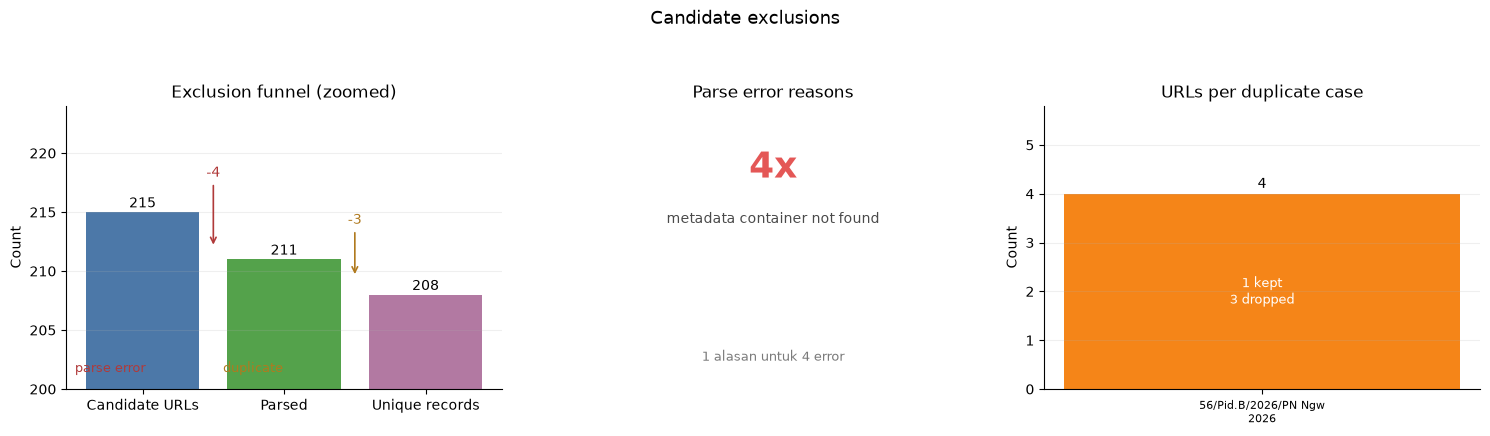

In [20]:
import matplotlib.pyplot as plt

fig_ex, axes_ex = plt.subplots(1, 3, figsize=(15, 4.4))
fig_ex.suptitle("Candidate exclusions", fontsize=13)

funnel_ex_labels = ["Candidate URLs", "Parsed", "Unique records"]
funnel_ex_values = [
    excluded["candidate_urls"],
    excluded["candidate_urls"] - excluded["parse_errors"],
    excluded["unique_records"],
]
axes_ex[0].bar(funnel_ex_labels, funnel_ex_values, color=["#4C78A8", "#54A24B", "#B279A2"])
axes_ex[0].set_ylim(200, 224)
axes_ex[0].set_title("Exclusion funnel (zoomed)")
axes_ex[0].set_ylabel("Count")
for slot, value in enumerate(funnel_ex_values):
    axes_ex[0].text(slot, value + 0.4, str(value), ha="center", fontsize=10)
axes_ex[0].annotate(
    f"-{excluded['parse_errors']}",
    xy=(0.5, 212), xytext=(0.5, 218), ha="center", fontsize=10,
    color="#B03A3A", arrowprops=dict(arrowstyle="->", color="#B03A3A", lw=1.2),
)
axes_ex[0].annotate(
    f"-{excluded['duplicates']}",
    xy=(1.5, 209.5), xytext=(1.5, 214), ha="center", fontsize=10,
    color="#B07A1F", arrowprops=dict(arrowstyle="->", color="#B07A1F", lw=1.2),
)
axes_ex[0].text(
    0.02, 0.06, "parse error", transform=axes_ex[0].transAxes,
    fontsize=9, color="#B03A3A", ha="left",
)
axes_ex[0].text(
    0.36, 0.06, "duplicate", transform=axes_ex[0].transAxes,
    fontsize=9, color="#B07A1F", ha="left",
)

reason_labels = list(error_reasons)[:5]
reason_values = [error_reasons[reason] for reason in reason_labels]
axes_ex[1].axis("off")
axes_ex[1].set_title("Parse error reasons")
for slot, (reason, value) in enumerate(zip(reason_labels, reason_values)):
    axes_ex[1].text(
        0.5, 0.78 - slot * 0.24, f"{value}x",
        ha="center", va="center", fontsize=26, color="#E45756", weight="bold",
    )
    axes_ex[1].text(
        0.5, 0.60 - slot * 0.24, reason,
        ha="center", va="center", fontsize=10, color="#4A4A4A",
    )
axes_ex[1].text(
    0.5, 0.10,
    f"{len(reason_labels)} alasan untuk {excluded['parse_errors']} error",
    ha="center", fontsize=9, color="#7A7A7A",
)

case_labels = [f"{case}\n{year}" for case, year, _ in duplicates_by_case]
case_values = [count + 1 for count in duplicates_by_case.values()]
axes_ex[2].bar(case_labels, case_values, color="#F58518", width=0.4)
axes_ex[2].set_ylim(0, max(case_values) * 1.45)
axes_ex[2].set_title("URLs per duplicate case")
axes_ex[2].set_ylabel("Count")
for slot, value in enumerate(case_values):
    axes_ex[2].text(slot, value + 0.12, str(value), ha="center", fontsize=10)
axes_ex[2].text(
    0, case_values[0] / 2, "1 kept\n3 dropped",
    ha="center", va="center", fontsize=9, color="white",
)
axes_ex[2].tick_params(axis="x", labelsize=8)

for slot, axis in enumerate(axes_ex):
    if slot == 1:
        continue
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(axis="y", alpha=0.2)

fig_ex.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### Validation

Validasi listing menghitung referensi dan URL unik. Setelah batch detail tersedia, validasi penuh memeriksa kasus unik, field wajib, cakupan pengadilan dan kategori, serta skema 21 kolom.

In [21]:
df = pd.read_csv(OUTPUT_CSV_PATH, dtype="string", keep_default_na=False)
required = ["nomor", "tahun", "tanggal_register", "lembaga_peradilan"]
case_fields = ["nomor", "tahun", "tanggal_register"]
missing = {field: int(df[field].eq("").sum()) for field in required}
normalized_cases = (
    df[case_fields]
    .apply(lambda column: column.str.replace(r"\s+", "", regex=True).str.upper())
    .agg("|".join, axis=1)
)
category_text = (df["klasifikasi"] + " " + df["kata_kunci"]).str.upper()
report = {
    "rows": len(df),
    "detail_errors": len(json.loads(ERROR_PATH.read_text(encoding="utf-8"))["errors"]),
    "columns": len(df.columns),
    "schema_matches": list(df.columns) == META_FIELDS,
    "unique_cases": int(normalized_cases.nunique()),
    "duplicate_cases": int(normalized_cases.duplicated().sum()),
    "unique_numbers": int(df["nomor"].nunique()),
    "duplicate_numbers": int(df["nomor"].duplicated().sum()),
    "missing_required": missing,
    "court_rows": int(
        df["lembaga_peradilan"]
        .str.contains(COURT_NAME, case=False, regex=False, na=False)
        .sum()
    ),
    "category_rows": int(
        category_text.str.contains(CATEGORY_NAME, case=False, regex=False).sum()
    ),
    "download_url_rows": int(
        df["url"]
        .str.contains(
            r"/direktori/download_file/|\.pdf(?:$|\?)", case=False, regex=True
        )
        .sum()
    ),
    "source_category": CATEGORY_NAME,
}
if (
    report["rows"] < MIN_RECORDS
    or not report["schema_matches"]
    or report["unique_cases"] < MIN_RECORDS
    or report["duplicate_cases"] != 0
    or any(missing.values())
    or report["court_rows"] != report["rows"]
    or report["category_rows"] != report["rows"]
):
    raise ValueError(json.dumps(report, ensure_ascii=False))
fill_counts = {field: int(df[field].ne("").sum()) for field in META_FIELDS}
fill_table = "\n".join(
    f"  {field:26s} {count:4d}/{report['rows']}"
    for field, count in fill_counts.items()
)
print(
    json.dumps(report, ensure_ascii=False, indent=2)
    + "\n\nFilled fields per column:\n"
    + fill_table
)

{
  "rows": 208,
  "detail_errors": 4,
  "columns": 21,
  "schema_matches": true,
  "unique_cases": 208,
  "duplicate_cases": 0,
  "unique_numbers": 208,
  "duplicate_numbers": 0,
  "missing_required": {
    "nomor": 0,
    "tahun": 0,
    "tanggal_register": 0,
    "lembaga_peradilan": 0
  },
  "court_rows": 208,
  "category_rows": 208,
  "download_url_rows": 187,
  "source_category": "PIDANA UMUM"
}

Filled fields per column:
  terdakwa                    208/208
  penuntut_umum               202/208
  nomor                       208/208
  tingkat_proses              208/208
  klasifikasi                 208/208
  kata_kunci                  208/208
  tahun                       208/208
  tanggal_register            208/208
  lembaga_peradilan           208/208
  jenis_lembaga_peradilan     208/208
  hakim_ketua                 208/208
  hakim_anggota               208/208
  panitera                    208/208
  amar                        208/208
  amar_lainnya                208/20

### Output Interpretation
Validasi memeriksa skema 21 kolom, field wajib, jumlah kasus unik, nama pengadilan, dan kategori PIDANA UMUM. Output menunjukkan 208 baris, 208 identitas kasus unik, nol nomor putusan duplikat, dan tidak ada field wajib yang kosong. Grafik kelengkapan dan catatan kualitas data di bawah menjelaskan field yang tidak terisi pada semua halaman. Tabel `Filled fields per column` menampilkan jumlah nilai yang terisi pada setiap kolom tanpa mencetak isi baris data.

### Results Visualization

Grafik berikut dibuat dari CSV hasil eksekusi dan ringkasan validasi. Grafik merangkum pengumpulan data, distribusi tahun, topik kasus, kelengkapan field, dan sumber setiap URL tersimpan.

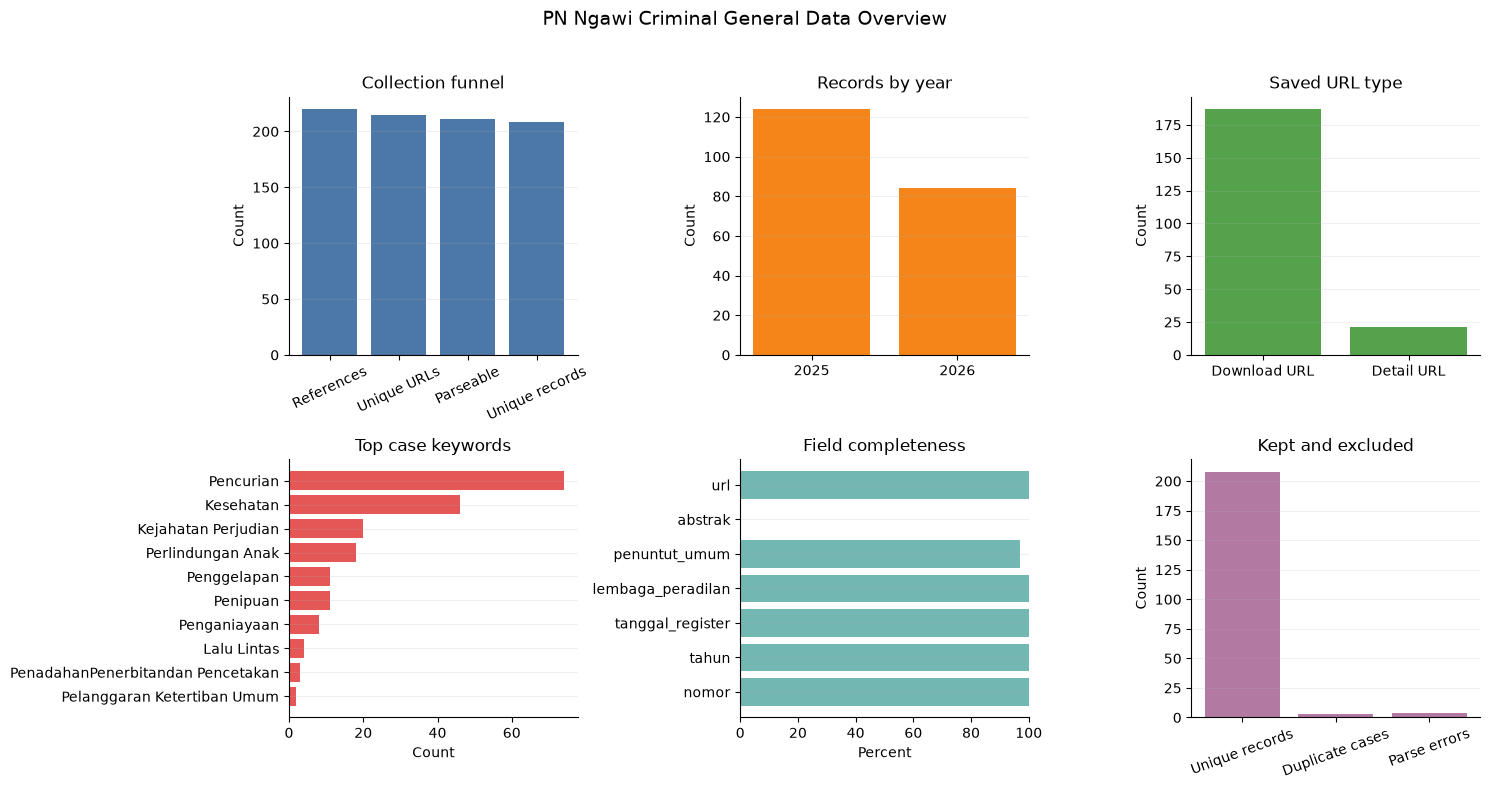

In [22]:
import matplotlib.pyplot as plt

total_references = sum(item["references"] for item in listing_stats)
valid_detail_count = len(candidate_urls) - len(error_report["errors"])
duplicate_case_count = valid_detail_count - len(df)
funnel_values = [total_references, len(candidate_urls), valid_detail_count, len(df)]
funnel_labels = ["References", "Unique URLs", "Parseable", "Unique records"]

year_counts = df["tahun"].value_counts().sort_index()
keyword_counts = df["kata_kunci"].replace("", "(empty)").value_counts().head(10)
url_counts = pd.Series({
    "Download URL": int(df["url"].str.contains("/direktori/download_file/", regex=False).sum()),
    "Detail URL": int((~df["url"].str.contains("/direktori/download_file/", regex=False)).sum()),
})
quality_fields = ["nomor", "tahun", "tanggal_register", "lembaga_peradilan", "penuntut_umum", "abstrak", "url"]
quality_pct = df[quality_fields].ne("").mean().mul(100)
summary_counts = pd.Series({
    "Unique records": len(df),
    "Duplicate cases": duplicate_case_count,
    "Parse errors": len(error_report["errors"]),
})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("PN Ngawi Criminal General Data Overview", fontsize=14)

axes[0, 0].bar(funnel_labels, funnel_values, color="#4C78A8")
axes[0, 0].set_title("Collection funnel")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=25)

axes[0, 1].bar(year_counts.index, year_counts.values, color="#F58518")
axes[0, 1].set_title("Records by year")
axes[0, 1].set_ylabel("Count")

axes[0, 2].bar(url_counts.index, url_counts.values, color="#54A24B")
axes[0, 2].set_title("Saved URL type")
axes[0, 2].set_ylabel("Count")

axes[1, 0].barh(keyword_counts.index[::-1], keyword_counts.values[::-1], color="#E45756")
axes[1, 0].set_title("Top case keywords")
axes[1, 0].set_xlabel("Count")

axes[1, 1].barh(quality_fields, quality_pct.values, color="#72B7B2")
axes[1, 1].set_title("Field completeness")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_xlabel("Percent")

axes[1, 2].bar(summary_counts.index, summary_counts.values, color="#B279A2")
axes[1, 2].set_title("Kept and excluded")
axes[1, 2].set_ylabel("Count")
axes[1, 2].tick_params(axis="x", rotation=20)

for axis in axes.flat:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(axis="y", alpha=0.2)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Visualization Interpretation
Diagram funnel menunjukkan perubahan dari referensi listing menjadi record unik yang dapat diproses. Grafik tahun memperlihatkan bahwa sampel tidak hanya berasal dari satu tahun, sedangkan grafik kata kunci menunjukkan topik kasus yang paling sering muncul. Grafik kelengkapan memisahkan field wajib dari field yang tidak tersedia pada halaman sumber. Grafik URL membedakan tautan unduh langsung dan fallback ke halaman detail, sedangkan grafik terakhir mencatat galat server yang ditangani dan kasus duplikat yang dibuang.

## Data Quality

Field identitas wajib terisi pada setiap record final. Kolom `abstrak` kosong pada halaman detail sumber, sehingga field tetap dipertahankan dalam skema 21 kolom tetapi tidak dijadikan syarat filtering. Kolom `penuntut_umum` tidak tersedia pada sebagian record, dan 21 record memakai URL detail karena tautan unduh langsung tidak ditemukan. Empat halaman mengembalikan galat server dan dikeluarkan dari CSV; jumlah sisanya tetap melampaui minimum tugas.

## Field Schema

| Group | Fields |
|---|---|
| Parties | `terdakwa`, `penuntut_umum` |
| Case identity | `nomor`, `tahun`, `tanggal_register` |
| Court | `lembaga_peradilan`, `jenis_lembaga_peradilan` |
| Panel and clerk | `hakim_ketua`, `hakim_anggota`, `panitera` |
| Decision | `amar`, `amar_lainnya`, `catatan_amar` |
| Schedule | `tanggal_musyawarah`, `tanggal_dibacakan` |
| Additional information | `kaidah`, `abstrak` |
| Source | `url` |

## Conclusion

Jalur scraping langsung dijalankan lebih dahulu dan ditolak server dengan `403` pada halaman putusan pertama. Penolakan itu dicatat sebagai fakta, tidak diulang, dan pengumpulan dialihkan ke snapshot lokal. Jalur kedua menghasilkan 215 URL kandidat dari sebelas halaman listing, lalu 208 record metadata unik dalam CSV 21 kolom.

Validasi memastikan 208 identitas kasus unik tanpa nomor putusan duplikat, field identitas wajib terisi lengkap, dan seluruh record berada pada PN Ngawi kategori Criminal Umum. Pembuktian asal-usul data menunjukkan setiap snapshot listing menyatakan nomor halamannya sendiri di dalam markup, dan daftar kandidat dapat dibangun ulang dari berkas yang sama.

Keterbatasan yang tersisa: empat halaman detail mengembalikan galat server dan dikeluarkan dari CSV, kolom abstrak kosong pada halaman sumber, dan 21 record memakai tautan halaman detail karena tautan unduh langsung tidak ditemukan.